In [2]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import cv2
import numpy as np

c:\Users\sriva\miniconda3\envs\deep-learning-latest\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


In [4]:
device = torch.device("cpu")

print(device)

cpu


In [9]:
unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

unet.load_state_dict(
    torch.load(
        r"D:\BMU\BMU SEM 4\Thesis\Implmentation\reports\results\segmentation\unet\best_unet.pth",
        map_location=device
    )
)

unet = unet.to(device)
unet.eval()

print("U-Net loaded successfully")

U-Net loaded successfully


In [10]:
deeplab = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

deeplab.load_state_dict(
    torch.load(
        r"D:\BMU\BMU SEM 4\Thesis\Implmentation\reports\results\segmentation\deeplabv3+\best_deeplabv3plus.pth",
        map_location=device
    )
)

deeplab = deeplab.to(device)
deeplab.eval()

print("DeepLabV3+ loaded successfully")

DeepLabV3+ loaded successfully


In [11]:
dummy = torch.randn(
    1,
    3,
    640,
    640
).to(device)

with torch.no_grad():

    out1 = unet(dummy)
    out2 = deeplab(dummy)

print("UNet:", out1.shape)
print("DeepLab:", out2.shape)

UNet: torch.Size([1, 1, 640, 640])
DeepLab: torch.Size([1, 1, 640, 640])


In [14]:
import kagglehub

path = kagglehub.dataset_download("cvvlearner/a-crack-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.37G/4.37G [05:13<00:00, 15.0MB/s] 

Extracting files...


Path to dataset files: C:\Users\sriva\.cache\kagglehub\datasets\cvvlearner\a-crack-dataset\versions\3


In [15]:
import os

DATASET_ROOT = r"C:\Users\sriva\.cache\kagglehub\datasets\cvvlearner\a-crack-dataset\versions\3"

IMG_DIR = os.path.join(
    DATASET_ROOT,
    "Crack segmentation",
    "Crack segmentation",
    "img"
)

MASK_DIR = os.path.join(
    DATASET_ROOT,
    "Crack segmentation",
    "Crack segmentation",
    "mask"
)

print(IMG_DIR)
print(MASK_DIR)

C:\Users\sriva\.cache\kagglehub\datasets\cvvlearner\a-crack-dataset\versions\3\Crack segmentation\Crack segmentation\img
C:\Users\sriva\.cache\kagglehub\datasets\cvvlearner\a-crack-dataset\versions\3\Crack segmentation\Crack segmentation\mask


In [16]:
from sklearn.model_selection import train_test_split

image_files = sorted(os.listdir(IMG_DIR))

train_files, temp_files = train_test_split(
    image_files,
    test_size=0.2,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.5,
    random_state=42
)

print("Test Images:", len(test_files))

Test Images: 163


In [41]:
idx = 25

image_file = test_files[idx]

print(image_file)

035add11.jpg


In [42]:
import cv2
import numpy as np

image_path = os.path.join(
    IMG_DIR,
    image_file
)

mask_path = os.path.join(
    MASK_DIR,
    image_file.replace(".jpg", ".png")
)

image = cv2.imread(image_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)

mask = (mask > 127).astype(np.float32)

print(image.shape)
print(mask.shape)

(640, 640, 3)
(640, 640)


In [43]:
import torch

image_tensor = (
    torch.tensor(
        image.astype(np.float32) / 255.0
    )
    .permute(2,0,1)
    .unsqueeze(0)
    .float()
)

In [44]:
with torch.no_grad():

    unet_pred = unet(image_tensor)

    deeplab_pred = deeplab(image_tensor)

    unet_pred = torch.sigmoid(unet_pred)

    deeplab_pred = torch.sigmoid(deeplab_pred)

    unet_pred = (
        unet_pred > 0.5
    ).float()

    deeplab_pred = (
        deeplab_pred > 0.5
    ).float()

In [45]:
unet_mask = (
    unet_pred
    .squeeze()
    .cpu()
    .numpy()
)

deeplab_mask = (
    deeplab_pred
    .squeeze()
    .cpu()
    .numpy()
)

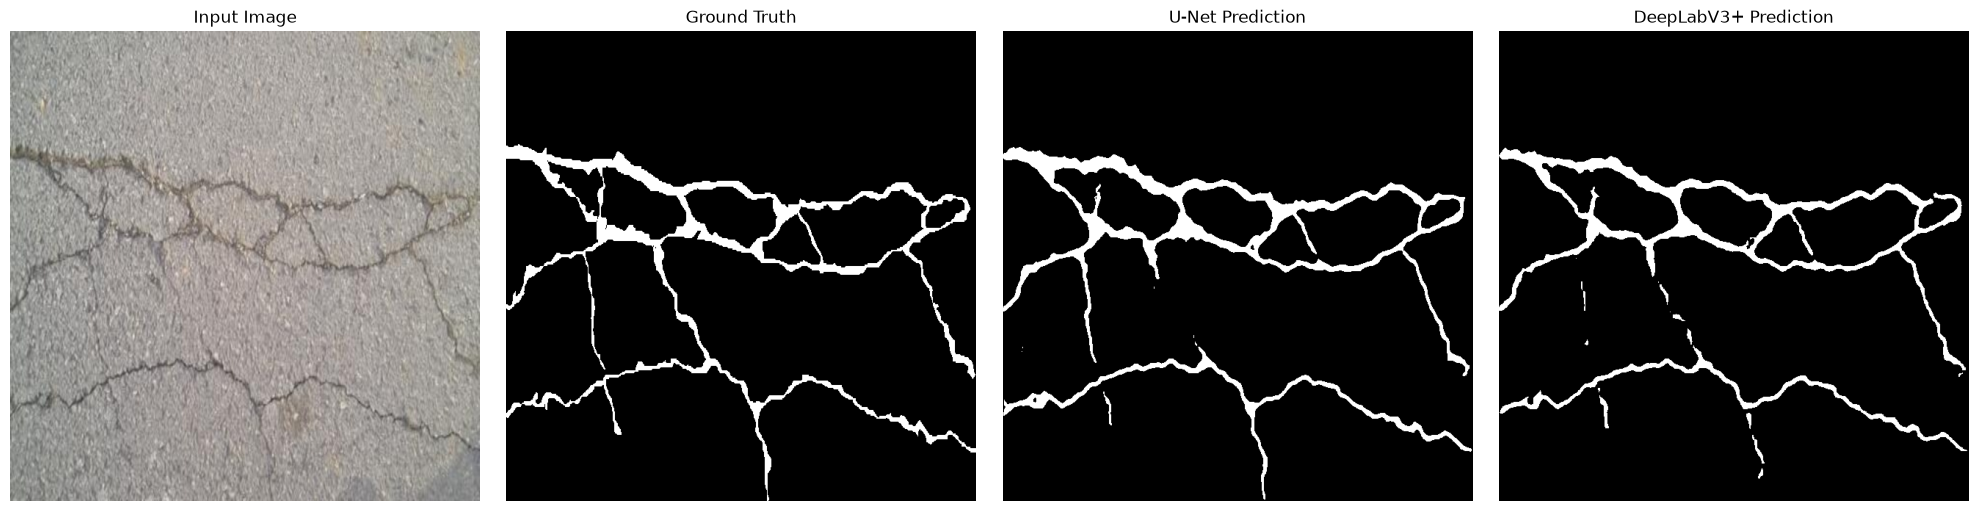

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20,5)
)

axes[0].imshow(image)
axes[0].set_title("Input Image")

axes[1].imshow(
    mask,
    cmap="gray"
)
axes[1].set_title("Ground Truth")

axes[2].imshow(
    unet_mask,
    cmap="gray"
)
axes[2].set_title("U-Net Prediction")

axes[3].imshow(
    deeplab_mask,
    cmap="gray"
)
axes[3].set_title("DeepLabV3+ Prediction")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "figure_14_segmentation_comparison.png",
    dpi=300
)

plt.show()